# IMPORT LIBRARIES

In [171]:
# PLOTTING & DATA STUFF
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import joblib


# DIM REDUCTION
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from openTSNE import TSNE
from sklearn.manifold import Isomap
import umap

# OUTLIERS
from pyod.models.knn import KNN
from pyod.models.abod import ABOD
from pyod.models.lof import LOF
from pyod.models.iforest import IsolationForest

# HELPERS
from utils import backup_dataframe, load_latest_backup


In [172]:
#!pip install openTSNE
#!pip install umap-learn
#!pip install pyod

# LOAD CSV

In [173]:
pd.set_option("display.max_colwidth", None)  # Show full content in columns
pd.set_option("display.max_rows", None)

In [174]:
df = pd.read_csv("dataset/train_pre_outlier.csv")

In [175]:
df.columns

Index(['Unnamed: 0', 'runtimeMinutes', 'awardWins', 'numVotes',
       'awardNominationsExcludeWins', 'canHaveEpisodes', 'isAdult',
       'numRegions', 'userReviewsTotal', 'countryOfOrigin', 'genres',
       'castNumber', 'companiesNumber', 'averageRating', 'externalLinks',
       'writerCredits', 'directorsCredits', 'soundMixes', 'quotesTotal',
       'release_decade', 'num_genres', 'has_awards', 'word_count',
       'num_countries', 'award_ratio', 'total_multimedia', 'rating_category',
       'sentiment_Negative', 'sentiment_Neutral', 'sentiment_Positive',
       'titleType_movie', 'titleType_short', 'titleType_tvEpisode',
       'titleType_tvMiniSeries', 'titleType_tvMovie', 'titleType_tvSeries',
       'titleType_tvShort', 'titleType_tvSpecial', 'titleType_video',
       'titleType_videoGame', 'continent', 'continent_Africa',
       'continent_Asia', 'continent_Europe', 'continent_North America',
       'continent_Oceania', 'continent_Other', 'continent_South America',
       'fil

# FAST CHECK AND PROCESS

In [176]:
df.shape

(116539, 67)

In [177]:
df.head()

,Unnamed: 0,runtimeMinutes,awardWins,numVotes,awardNominationsExcludeWins,canHaveEpisodes,isAdult,numRegions,userReviewsTotal,countryOfOrigin,...,genre_Romance,genre_Short,filtered_soundMixes,mix_dolby,mix_dolby_digital,mix_mono,mix_other_mix,mix_silent,mix_stereo,mix_unknown
0,0,-0.500000,0.0,-0.173469,0.0,0,0,0.0,0.0,['US'],...,0,1,['mono'],0,0,1,0,0,0,0
1,1,-0.557692,0.0,-0.204082,0.0,0,0,0.0,0.0,['US'],...,0,0,['mono'],0,0,1,0,0,0,0
2,2,0.134615,0.0,0.295918,0.0,0,0,0.0,1.0,['US'],...,0,0,['mono'],0,0,1,0,0,0,0
3,3,0.269231,0.0,-0.091837,0.0,0,0,0.0,1.0,['US'],...,0,0,['mono'],0,0,1,0,0,0,0
4,4,-0.615385,0.0,0.275510,3.0,0,0,0.0,0.0,['BE'],...,0,1,['mono'],0,0,1,0,0,0,0


In [178]:
df = df.drop(columns=["Unnamed: 0"])

In [179]:
df.columns

Index(['runtimeMinutes', 'awardWins', 'numVotes',
       'awardNominationsExcludeWins', 'canHaveEpisodes', 'isAdult',
       'numRegions', 'userReviewsTotal', 'countryOfOrigin', 'genres',
       'castNumber', 'companiesNumber', 'averageRating', 'externalLinks',
       'writerCredits', 'directorsCredits', 'soundMixes', 'quotesTotal',
       'release_decade', 'num_genres', 'has_awards', 'word_count',
       'num_countries', 'award_ratio', 'total_multimedia', 'rating_category',
       'sentiment_Negative', 'sentiment_Neutral', 'sentiment_Positive',
       'titleType_movie', 'titleType_short', 'titleType_tvEpisode',
       'titleType_tvMiniSeries', 'titleType_tvMovie', 'titleType_tvSeries',
       'titleType_tvShort', 'titleType_tvSpecial', 'titleType_video',
       'titleType_videoGame', 'continent', 'continent_Africa',
       'continent_Asia', 'continent_Europe', 'continent_North America',
       'continent_Oceania', 'continent_Other', 'continent_South America',
       'filtered_genres',

In [180]:
df.shape

(116539, 66)

In [181]:
numerical_vars_to_check = [
    "runtimeMinutes",
    "awardWins",
    "numVotes",
    "awardNominationsExcludeWins",
    "numRegions",
    "userReviewsTotal",
    "castNumber",
    "companiesNumber",
    "averageRating",
    "externalLinks",
    "writerCredits",
    "directorsCredits",
    "quotesTotal",
    "release_decade",
    "num_genres",
    "word_count",
    "num_countries",
    "award_ratio",
    "total_multimedia",
]


In [182]:
cat = list(set(df.columns) - set(numerical_vars_to_check))

In [183]:
df_num = df.drop(cat, axis=1)

In [184]:
X = df_num.values

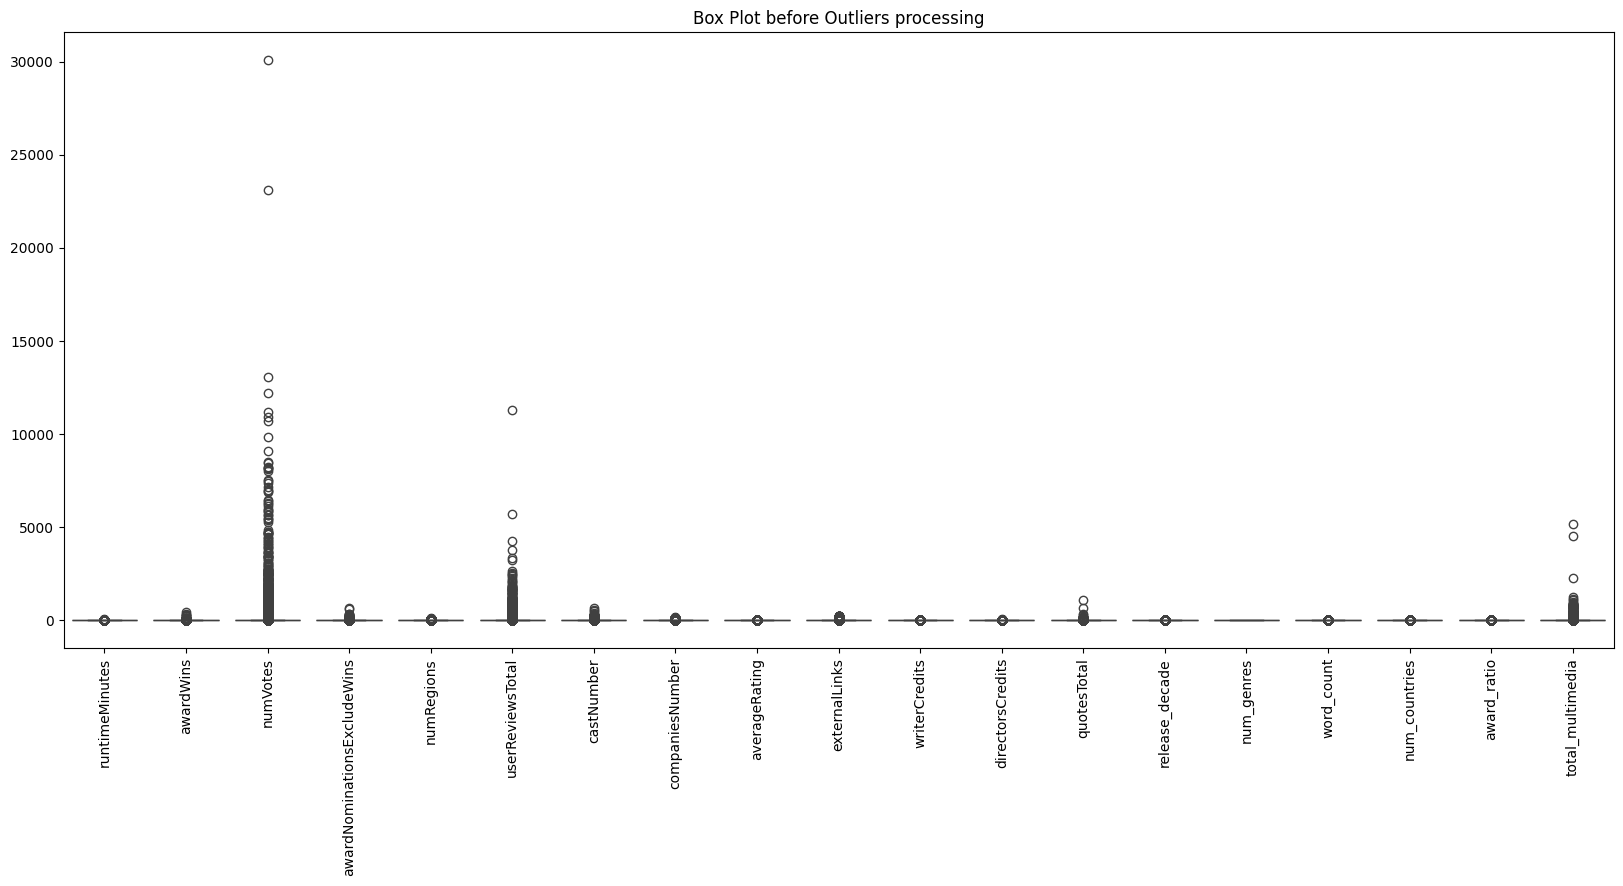

In [185]:
plt.figure(figsize=(20, 8))
sns.boxplot(df_num)
plt.xticks(rotation=90)
plt.title("Box Plot before Outliers processing")
plt.show()

# DIM REDUCTION

## PCA

In [186]:
pca = PCA(n_components=2)  # Scegli il numero di componenti principali desiderate
X_pca = pca.fit_transform(X)


/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


/var/folders/9v/f8wr4b9x0zdf_z5f4n5y_dr80000gn/T/ipykernel_71493/2570865273.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap="muted", alpha=0.5, s=5)
/var/folders/9v/f8wr4b9x0zdf_z5f4n5y_dr80000gn/T/ipykernel_71493/2570865273.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


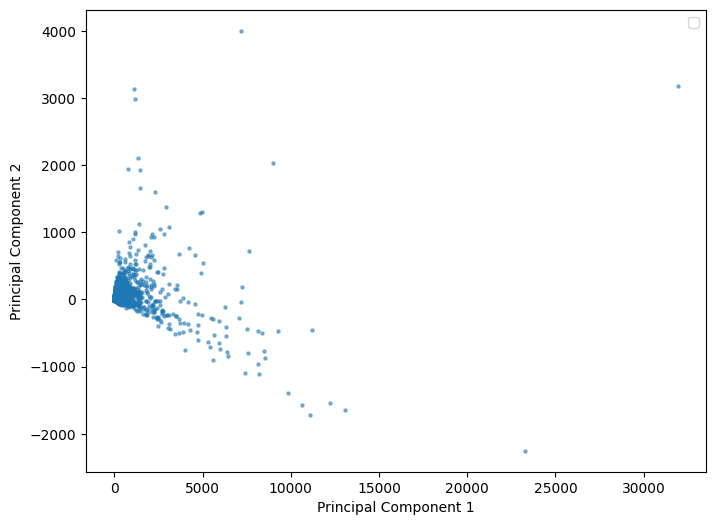

In [187]:
# Plot dei punti ridotti
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap="muted", alpha=0.5, s=5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [188]:
# Riduci la dimensionalità utilizzando PCA
pca = PCA(n_components=3)  # Scegli il numero di componenti principali desiderate
X_pca_3d = pca.fit_transform(X)

/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


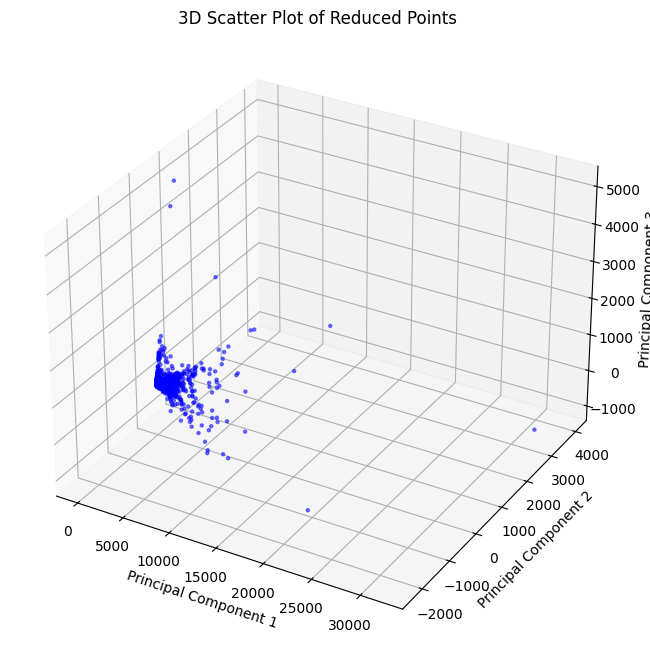

In [189]:
from mpl_toolkits.mplot3d import Axes3D

# 3D Scatter Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c="blue", alpha=0.5, s=5)

# Add labels
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.title("3D Scatter Plot of Reduced Points")
plt.show()

## T-SNE

In [190]:
#!pip install opentsne
# References: https://opentsne.readthedocs.io/en/stable/tsne_algorithm.html

/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


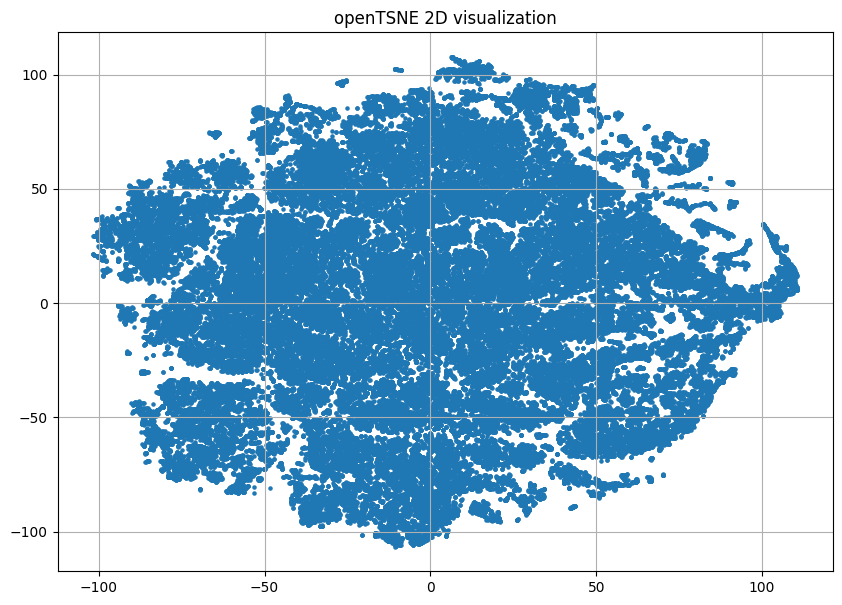

In [191]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    initialization="pca",  # inizia con PCA embedding
    n_jobs=8,  # usa CPU parallele
    random_state=42,
)

X_array = X  # <-- converti in array
X_embedded = tsne.fit(X_array)  # non direttamente X

plt.figure(figsize=(10, 7))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=5)
plt.title("openTSNE 2D visualization")
plt.grid(True)
plt.show()


In [194]:
np.save(file="arrays/x_tsne.npy", arr=X_embedded)

In [195]:
X_tsne = np.load("arrays/X_tsne.npy")

## UMAP

In [ ]:
#!pip install umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 9.0 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 10.6 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [165]:
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X)

/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [166]:
np.save("arrays/X_umap.npy", X_umap)

In [167]:
X_umap = np.load("arrays/X_umap.npy")

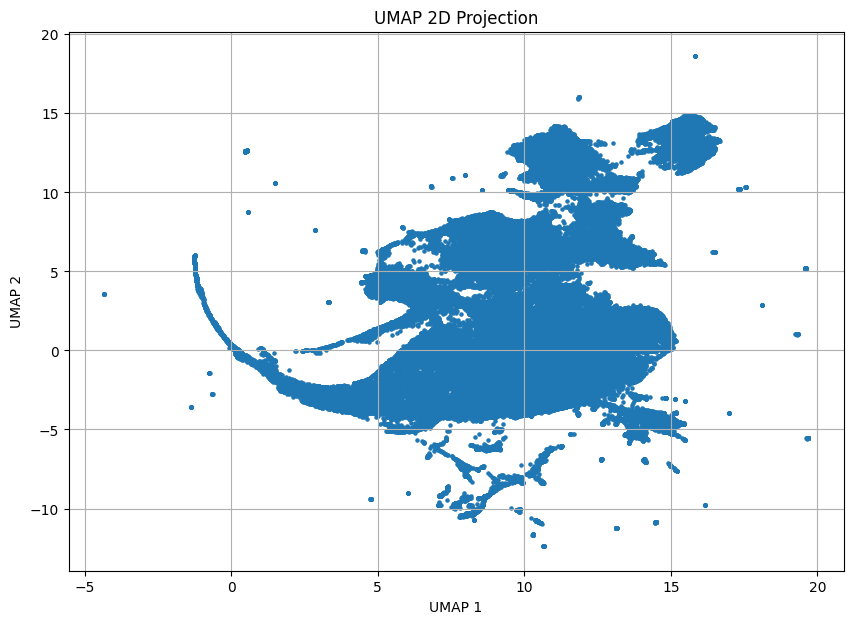

In [168]:
# Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=5)
plt.title("UMAP 2D Projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

In [196]:
X_umap.shape

(116539, 2)

In [197]:
X_tsne.shape

(116539, 2)

# DISTANCE BASED-APPROACH

In [198]:
#!pip install pyod

In [199]:
%time
# 1. Fit di KNN sui dati scalati (non su umap!)
knn_detector = KNN(contamination=0.01, method="mean")  # 1% outlier
knn_detector.fit(X)


CPU times: user 1 μs, sys: 1e+03 ns, total: 2 μs
Wall time: 5.01 μs


KNN(algorithm='auto', contamination=0.01, leaf_size=30, method='mean',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=5, p=2,
  radius=1.0)

In [200]:
# 2. Predizioni outlier
%time
outliers = knn_detector.predict(X)
np.unique(outliers, return_counts=True)

CPU times: user 4 μs, sys: 9 μs, total: 13 μs
Wall time: 4.05 μs


(array([0, 1]), array([115645,    894]))

In [201]:
i = np.where(outliers == 1)  # when comparing arrays of integers
i

(array([   277,    324,    453,    481,    835,    996,   1084,   1121,
          1147,   1239,   1333,   1540,   1549,   1558,   1586,   1598,
          1651,   1716,   1754,   1900,   1928,   1984,   2146,   2240,
          2901,   3135,   3919,   4028,   4173,   4209,   4244,   4598,
          4733,   4899,   5425,   5469,   5585,   5607,   5724,   5743,
          5834,   5953,   6060,   6300,   6311,   6337,   6344,   6401,
          6402,   6719,   7031,   7323,   7348,   7368,   7458,   7545,
          7778,   7913,   7929,   8289,   8468,   8487,   8488,   8874,
          9224,   9459,   9548,   9722,   9793,  10291,  10449,  10557,
         10568,  10579,  10634,  10714,  10892,  10945,  10995,  11047,
         11058,  11118,  11172,  11187,  11248,  11305,  11641,  11655,
         11717,  12025,  12072,  12286,  12355,  12638,  12640,  12682,
         12764,  12775,  13007,  13044,  13058,  13191,  13299,  13355,
         13357,  13366,  13717,  13769,  13789,  13817,  13851, 

In [202]:
# Ottieni gli indici degli outlier
outlier_knn = np.where(outliers == 1)[0]

In [203]:
outliers_knn = knn_detector.labels_  # oppure se hai salvato predict

In [204]:
outlier_knn_indices = np.where(outliers_knn == 1)[0]

In [205]:
np.save("arrays/outlier_indices_knn.npy", outlier_knn)

In [206]:
outlier_indices = np.load("arrays/outlier_indices_knn.npy")

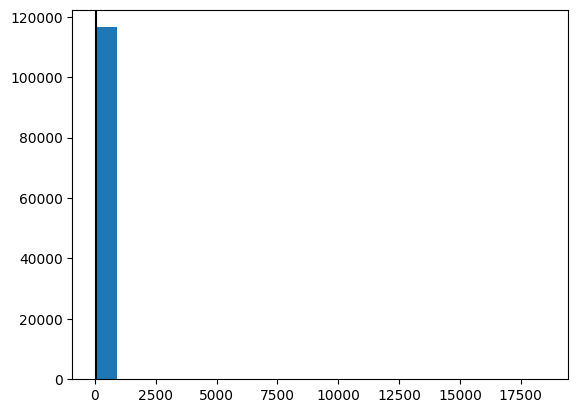

In [207]:
plt.hist(knn_detector.decision_scores_, bins=20)
plt.axvline(np.min(knn_detector.decision_scores_[np.where(outliers == 1)]), c="k")
plt.show()

In [208]:
palette = "dark"  # 'deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind'

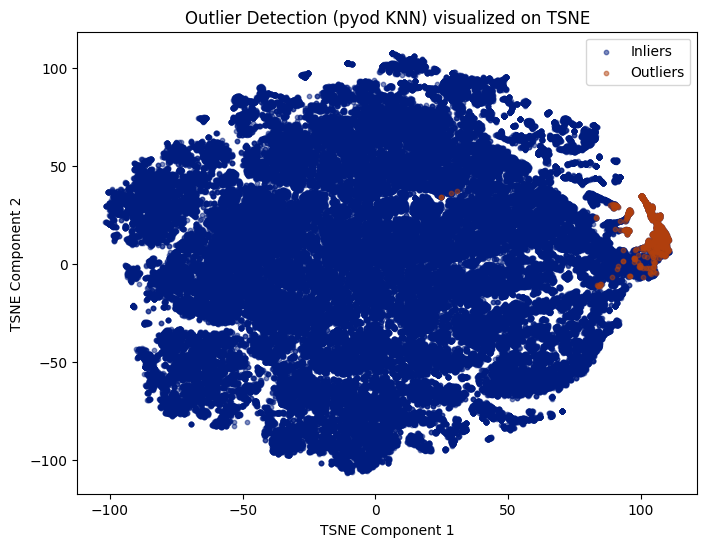

In [209]:
# TSNE plot
plt.figure(figsize=(8, 6))

# Plot inliers
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    label="Inliers",
    color=sns.color_palette(palette)[0],
    alpha=0.5,
    s=10,
)

# Plot outliers
plt.scatter(
    X_tsne[outlier_knn, 0],
    X_tsne[outlier_knn, 1],
    label="Outliers",
    color=sns.color_palette(palette)[1],
    alpha=0.5,
    s=10,
)

plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.legend()
plt.title("Outlier Detection (pyod KNN) visualized on TSNE")
plt.show()


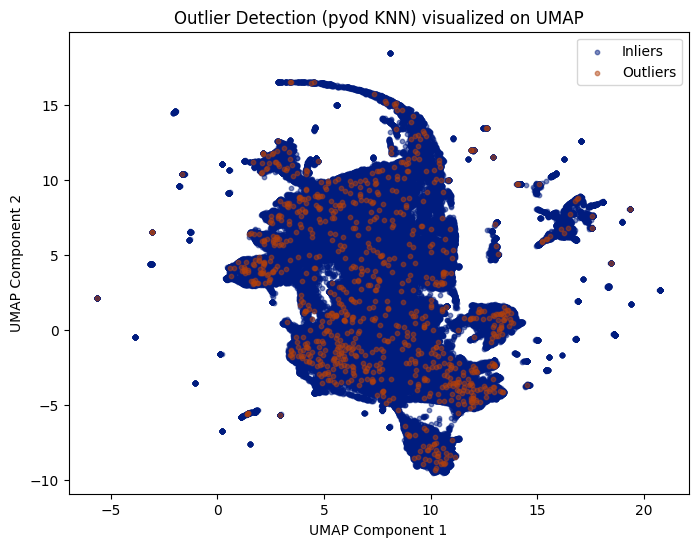

In [161]:
# TSNE plot
plt.figure(figsize=(8, 6))

# Plot inliers
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    label="Inliers",
    color=sns.color_palette(palette)[0],
    alpha=0.5,
    s=10,
)

# Plot outliers
plt.scatter(
    X_umap[outlier_knn, 0],
    X_umap[outlier_knn, 1],
    label="Outliers",
    color=sns.color_palette(palette)[1],
    alpha=0.5,
    s=10,
)

plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend()
plt.title("Outlier Detection (pyod KNN) visualized on UMAP")
plt.show()


(116539,)

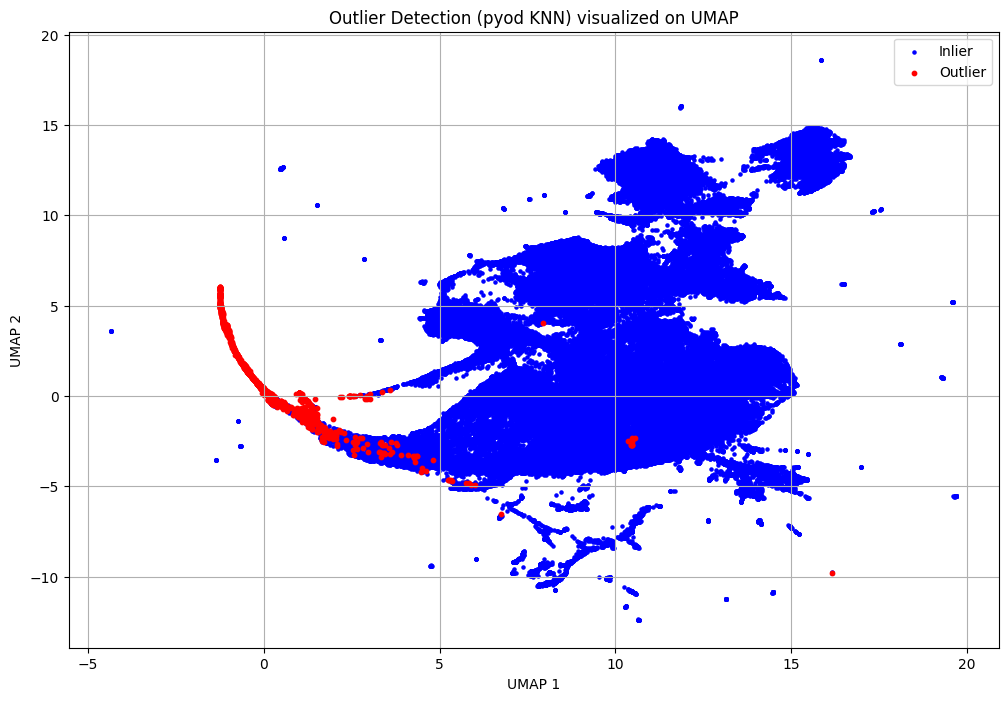

In [210]:
plt.figure(figsize=(12, 8))

plt.scatter(
    X_umap[outliers == 0, 0],
    X_umap[outliers == 0, 1],
    color="blue",
    s=5,
    label="Inlier",
)

plt.scatter(
    X_umap[outliers_knn == 1, 0],
    X_umap[outliers_knn == 1, 1],
    color="red",
    s=10,
    label="Outlier",
)

plt.title("Outlier Detection (pyod KNN) visualized on UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()


# ANGLE BASED-APPROACH

In [211]:
abod_detector = ABOD(contamination=0.01, n_neighbors=50, method="fast")
abod_detector.fit(X)

ABOD(contamination=0.01, method='fast', n_neighbors=50)

In [212]:
# Save the model
joblib.dump(abod_detector, "best_models/abod_model.joblib")


['best_models/abod_model.joblib']

In [213]:
abod_detector = joblib.load("best_models/abod_model.joblib")

In [214]:
outliers = abod_detector.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([115379,   1160]))

In [215]:
# outliers = abod_detector.labels_  # 0 = normale, 1 = outlier
scores = abod_detector.decision_scores_  # punteggio di anomalia continuo


In [216]:
outlier__abod = np.where(outliers == 1)[0]
print(len(outlier__abod))


1160


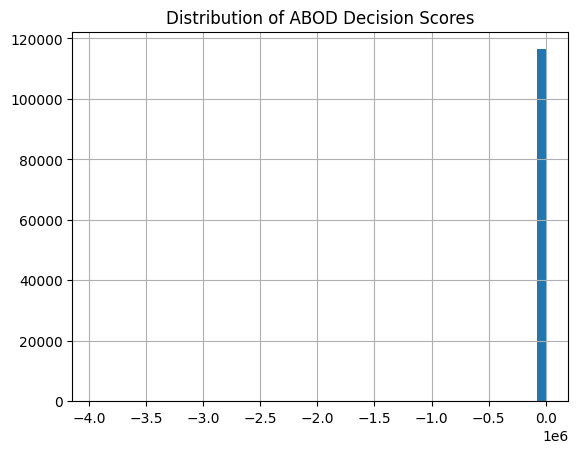

In [217]:
plt.hist(scores, bins=50)
plt.title("Distribution of ABOD Decision Scores")
plt.grid(True)
plt.show()

In [218]:
np.save("arrays/abod_model_prediction.npy", outliers)

In [219]:
outliers = np.load("arrays/abod_model_prediction.npy")

In [220]:
outliers_abod = abod_detector.labels_  # array 0/1
outlier_abod_indices = np.where(outliers_abod == 1)[0]

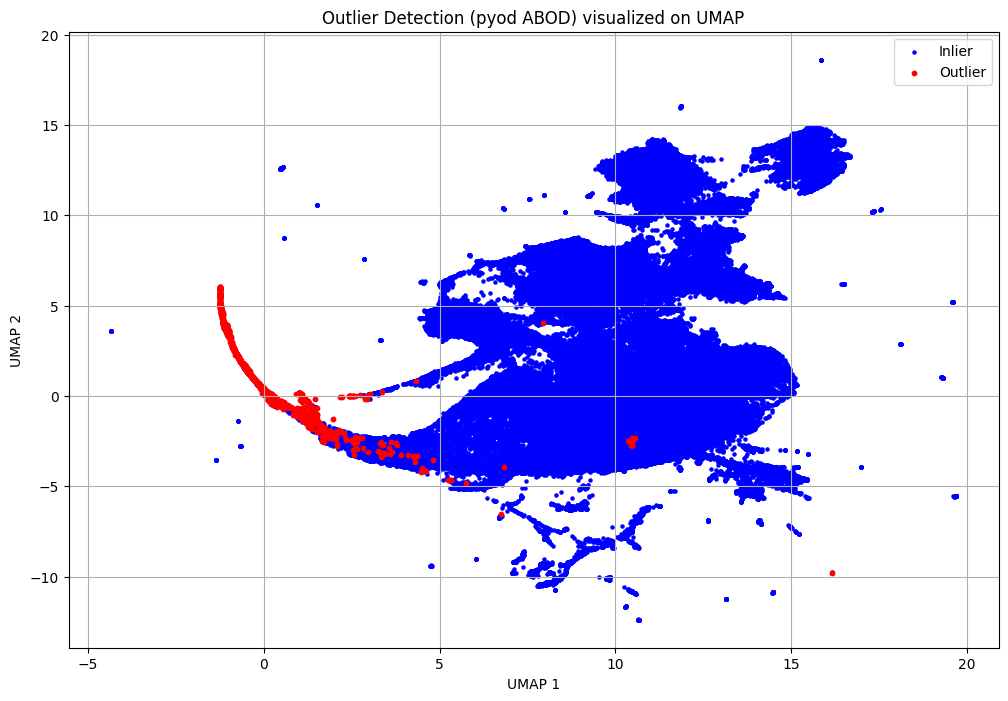

In [221]:
plt.figure(figsize=(12, 8))

plt.scatter(
    X_umap[abod_detector.labels_ == 0, 0],
    X_umap[abod_detector.labels_ == 0, 1],
    color="blue",
    s=5,
    label="Inlier",
)

# Disegna i punti anomali
plt.scatter(
    X_umap[abod_detector.labels_ == 1, 0],
    X_umap[abod_detector.labels_ == 1, 1],
    color="red",
    s=10,
    label="Outlier",
)

plt.title("Outlier Detection (pyod ABOD) visualized on UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()


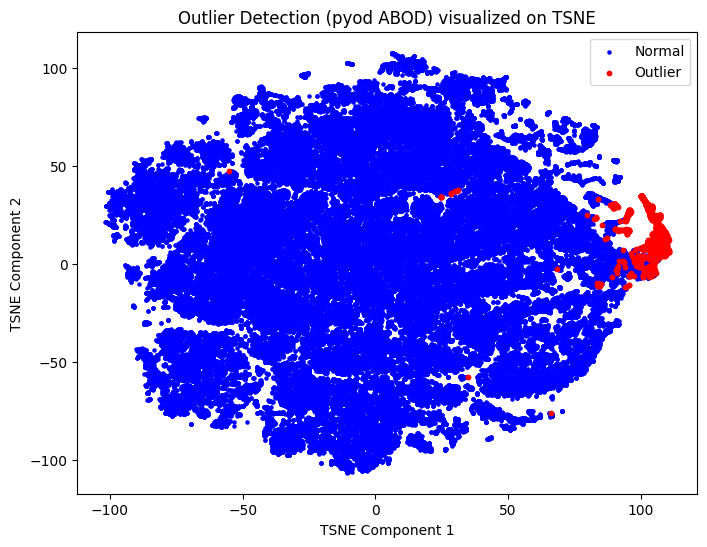

In [222]:
# TSNE plot
plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[abod_detector.labels_ == 0, 0],
    X_tsne[abod_detector.labels_ == 0, 1],
    color="blue",
    s=5,
    label="Normal",
)

plt.scatter(
    X_tsne[abod_detector.labels_ == 1, 0],
    X_tsne[abod_detector.labels_ == 1, 1],
    color="red",
    s=10,
    label="Outlier",
)

plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.legend()
plt.title("Outlier Detection (pyod ABOD) visualized on TSNE")
plt.show()


# DENSITY BASED-APPROACH

In [223]:
lof_detector = LOF(n_neighbors=10, contamination=0.01)
lof_detector.fit(X)

LOF(algorithm='auto', contamination=0.01, leaf_size=30, metric='minkowski',
  metric_params=None, n_jobs=1, n_neighbors=10, novelty=True, p=2)

In [224]:
outliers = lof_detector.labels_  # 0 = normale, 1 = outlier
scores = lof_detector.decision_scores_  # punteggio di anomalia continuo


In [225]:
outliers_lof = lof_detector.labels_  # array 0/1
outlier_lof_indices = np.where(outliers_lof == 1)[0]

In [226]:
np.unique(outliers, return_counts=True)

(array([0, 1]), array([115373,   1166]))

In [227]:
outlier_lof = np.where(outliers == 1)[0]

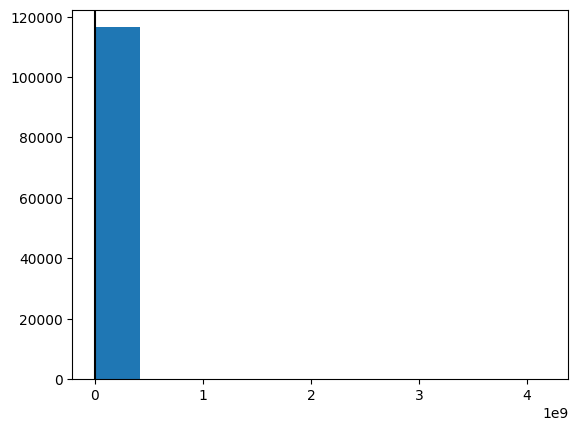

In [228]:
plt.hist(lof_detector.decision_scores_, bins=10)
plt.axvline(np.min(lof_detector.decision_scores_[np.where(outliers == 1)]), c="k")
plt.show()

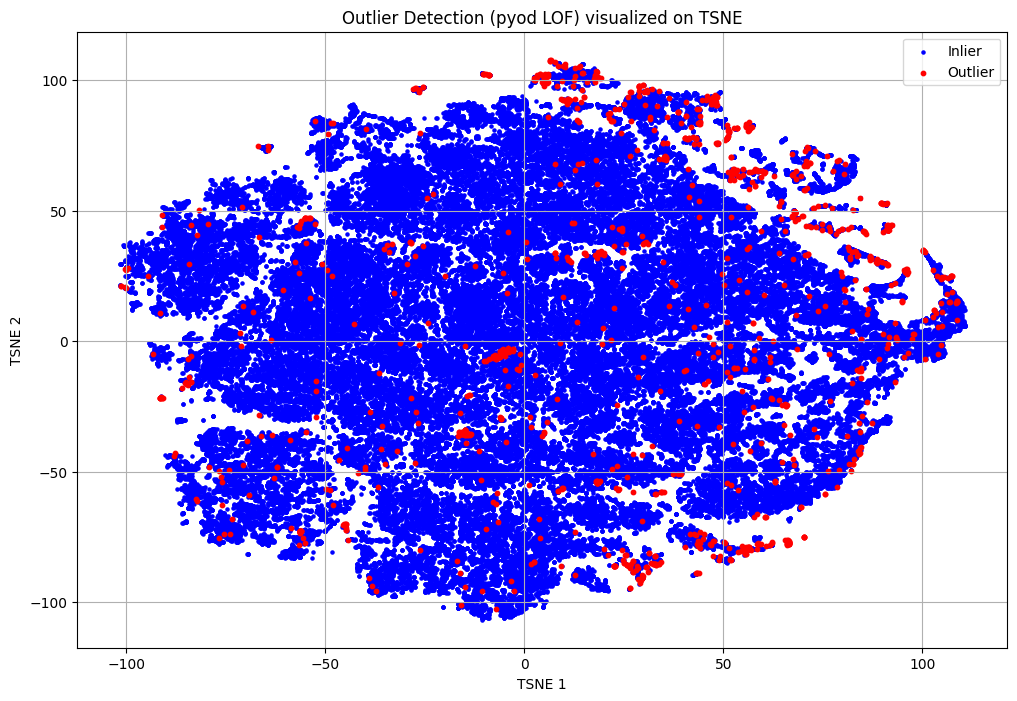

In [229]:
plt.figure(figsize=(12, 8))

plt.scatter(
    X_tsne[lof_detector.labels_ == 0, 0],
    X_tsne[lof_detector.labels_ == 0, 1],
    color="blue",
    s=5,
    label="Inlier",
)

plt.scatter(
    X_tsne[lof_detector.labels_ == 1, 0],
    X_tsne[lof_detector.labels_ == 1, 1],
    color="red",
    s=10,
    label="Outlier",
)

plt.title("Outlier Detection (pyod LOF) visualized on TSNE")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.legend()
plt.grid(True)
plt.show()


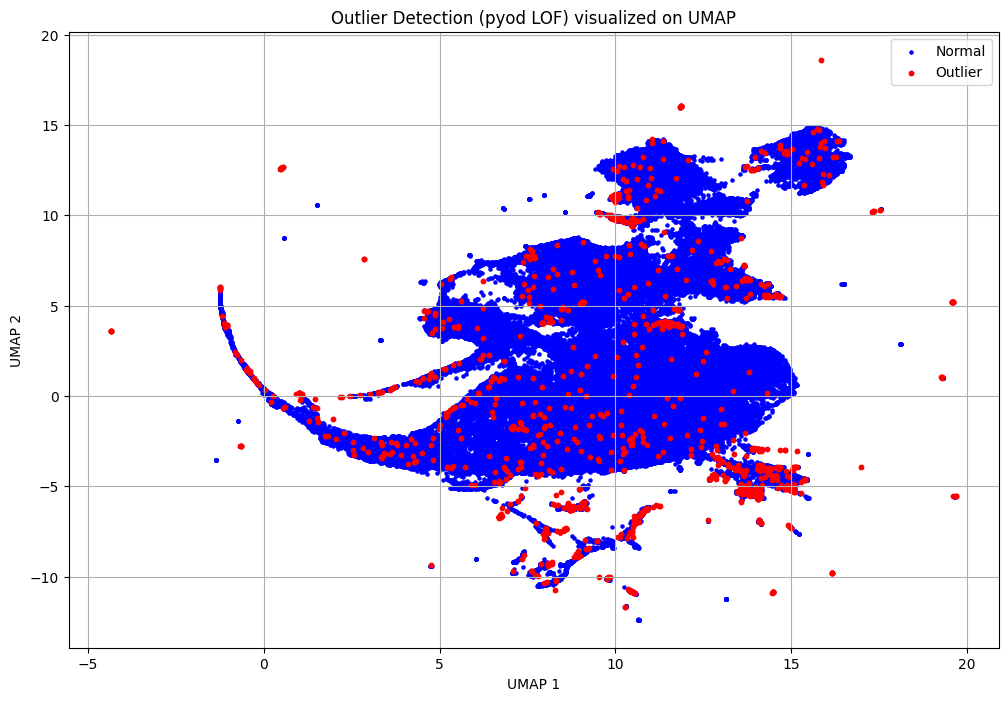

In [230]:
plt.figure(figsize=(12, 8))

# Disegna i punti normali
plt.scatter(
    X_umap[lof_detector.labels_ == 0, 0],
    X_umap[lof_detector.labels_ == 0, 1],
    color="blue",
    s=5,
    label="Normal",
)

# Disegna i punti anomali
plt.scatter(
    X_umap[lof_detector.labels_ == 1, 0],
    X_umap[lof_detector.labels_ == 1, 1],
    color="red",
    s=10,
    label="Outlier",
)

plt.title("Outlier Detection (pyod LOF) visualized on UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()


# ISOFOREST

In [231]:
isoforest_detector = IsolationForest(contamination=0.01)
isoforest_detector.fit(X)

IsolationForest(contamination=0.01)

In [232]:
outliers = isoforest_detector.predict(X)
np.unique(outliers, return_counts=True)

(array([-1,  1]), array([  1166, 115373]))

In [233]:
outlier_if = np.where(outliers == -1)[0]
print(len(outlier_if))


1166


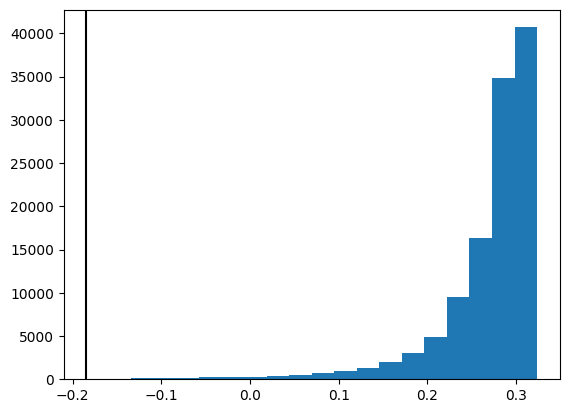

In [234]:
plt.hist(isoforest_detector.decision_function(X), bins=20)
plt.axvline(
    np.min(isoforest_detector.decision_function(X)[np.where(outliers == -1)]), c="k"
)
plt.show()

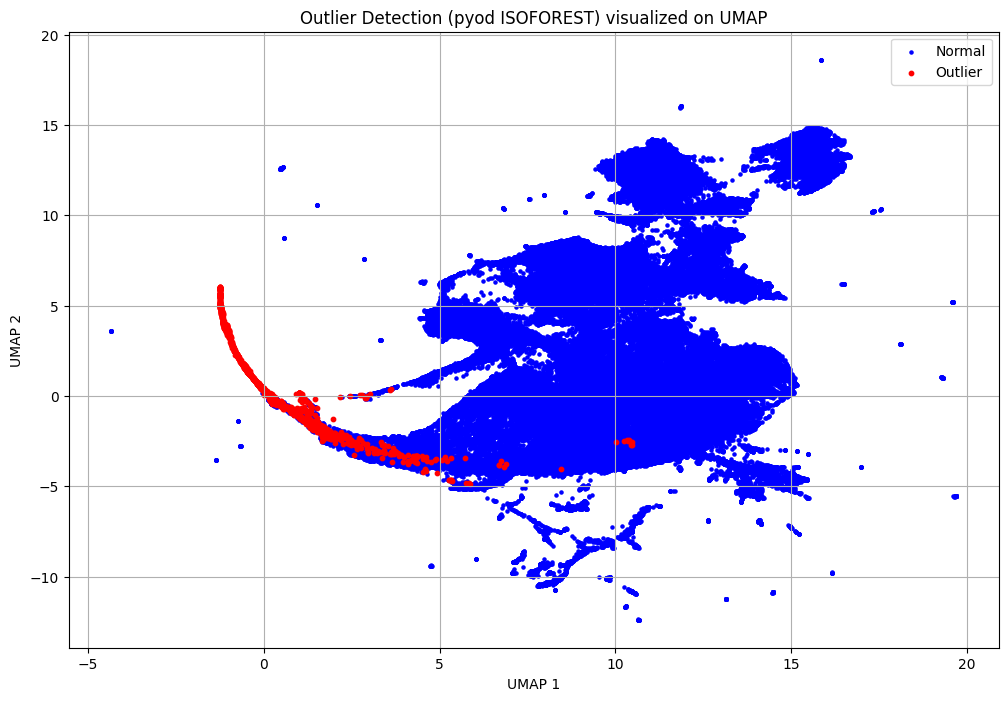

In [235]:
plt.figure(figsize=(12, 8))

# Disegna i punti normali
plt.scatter(X_umap[:, 0], X_umap[:, 1], color="blue", s=5, label="Normal")

# Disegna i punti anomali
plt.scatter(
    X_umap[outlier_if, 0], X_umap[outlier_if, 1], color="red", s=10, label="Outlier"
)

plt.title("Outlier Detection (pyod ISOFOREST) visualized on UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()

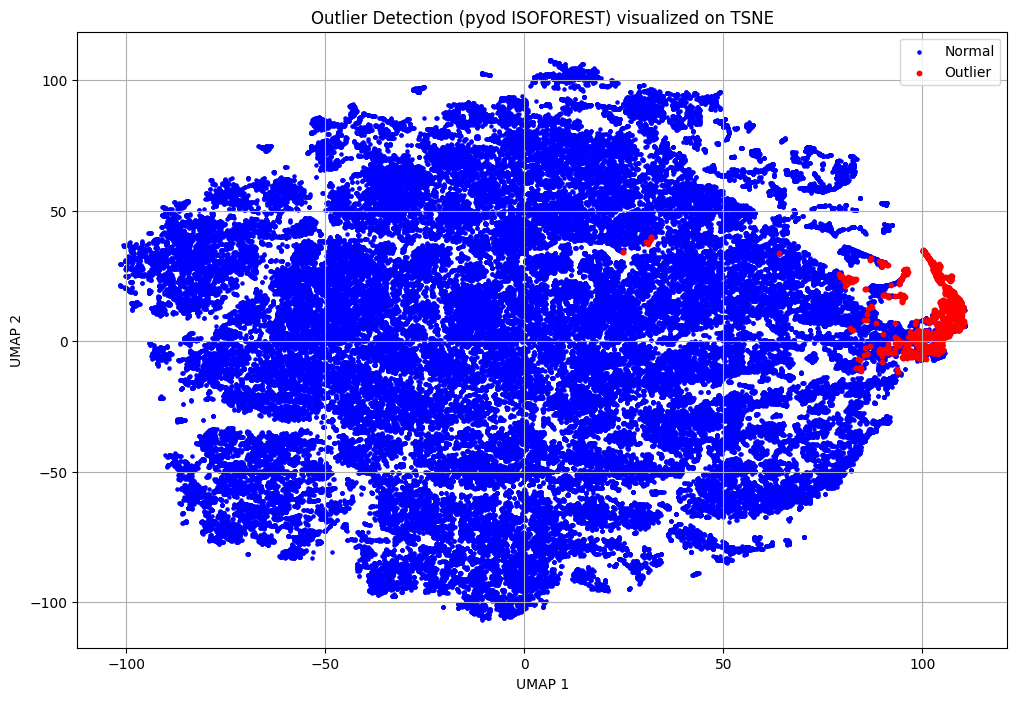

In [236]:
plt.figure(figsize=(12, 8))

# Disegna i punti normali
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], color="blue", s=5, label="Normal")

# Disegna i punti anomali
plt.scatter(
    X_tsne[outlier_if, 0], X_tsne[outlier_if, 1], color="red", s=10, label="Outlier"
)

plt.title("Outlier Detection (pyod ISOFOREST) visualized on TSNE")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()

# SUM UP

In [237]:
# intesection (KNN + ABOD + LOF + Isolation Forest)
outliers_common_all = np.intersect1d(
    np.intersect1d(
        np.intersect1d(outlier_knn_indices, outlier_abod_indices), outlier_lof_indices
    ),
    outlier_if,
)

# pairs interesection
knn_abod = np.intersect1d(outlier_knn_indices, outlier_abod_indices)
knn_lof = np.intersect1d(outlier_knn_indices, outlier_lof_indices)
knn_if = np.intersect1d(outlier_knn_indices, outlier_if)
abod_lof = np.intersect1d(outlier_abod_indices, outlier_lof_indices)
abod_if = np.intersect1d(outlier_abod_indices, outlier_if)
lof_if = np.intersect1d(outlier_lof_indices, outlier_if)

# unique outliers by each method
only_knn = np.setdiff1d(
    outlier_knn_indices,
    np.union1d(np.union1d(outlier_abod_indices, outlier_lof_indices), outlier_if),
)
only_abod = np.setdiff1d(
    outlier_abod_indices,
    np.union1d(np.union1d(outlier_knn_indices, outlier_lof_indices), outlier_if),
)
only_lof = np.setdiff1d(
    outlier_lof_indices,
    np.union1d(np.union1d(outlier_knn_indices, outlier_abod_indices), outlier_if),
)
only_if = np.setdiff1d(
    outlier_if,
    np.union1d(
        np.union1d(outlier_knn_indices, outlier_abod_indices), outlier_lof_indices
    ),
)

# --- STAMPA RISULTATI ---

print(
    f"🔵 Common outliers between the 4 methods (KNN, ABOD, LOF, Isolation Forest): {len(outliers_common_all)}"
)
print(f"🟠 Common outliers KNN-ABOD: {len(knn_abod)}")
print(f"🟠 Common outliers KNN-LOF: {len(knn_lof)}")
print(f"🟠 Common outliers KNN-IF: {len(knn_if)}")
print(f"🟠 Common outliers ABOD-LOF: {len(abod_lof)}")
print(f"🟠 Common outliers ABOD-IF: {len(abod_if)}")
print(f"🟠 Common outliers LOF-IF: {len(lof_if)}")

print(f"🔴 Unique outliers found only by KNN: {len(only_knn)}")
print(f"🔴 Unique outliers found only by ABOD: {len(only_abod)}")
print(f"🔴 Unique outliers found only by LOF: {len(only_lof)}")
print(f"🔴 Unique outliers found only by Isolation Forest: {len(only_if)}")


🔵 Common outliers between the 4 methods (KNN, ABOD, LOF, Isolation Forest): 68
🟠 Common outliers KNN-ABOD: 1126
🟠 Common outliers KNN-LOF: 92
🟠 Common outliers KNN-IF: 910
🟠 Common outliers ABOD-LOF: 91
🟠 Common outliers ABOD-IF: 910
🟠 Common outliers LOF-IF: 75
🔴 Unique outliers found only by KNN: 19
🔴 Unique outliers found only by ABOD: 20
🔴 Unique outliers found only by LOF: 1067
🔴 Unique outliers found only by Isolation Forest: 232


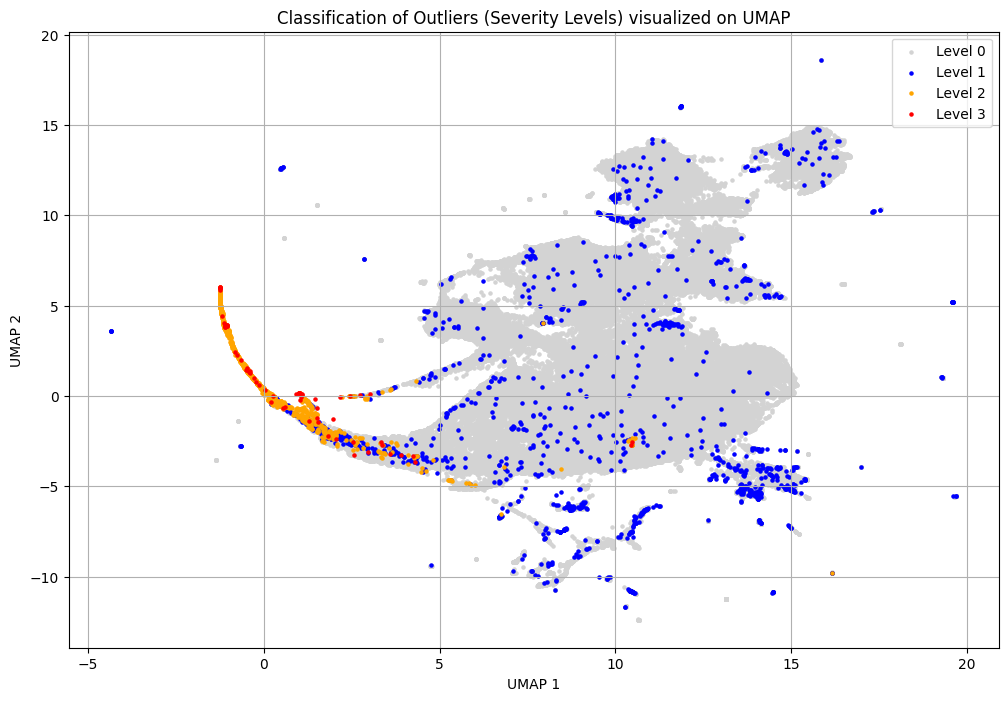

In [238]:
n_samples = X.shape[0]

outlier_level = np.zeros(n_samples)

# Hard Outliers (4 up)
outlier_level[outliers_common_all] = 3

# Moderate Outliers ( 2 or 3 methos)
# (every intersection 2 by 2, without the 4 ones)
moderate_outliers = np.unique(
    np.concatenate((knn_abod, knn_lof, knn_if, abod_lof, abod_if, lof_if))
)

# remove hard ones
moderate_outliers = np.setdiff1d(moderate_outliers, outliers_common_all)

outlier_level[moderate_outliers] = 2

# Weak Outliers (found only by 1 method)
weak_outliers = np.unique(np.concatenate((only_knn, only_abod, only_lof, only_if)))
outlier_level[weak_outliers] = 1

# Normal stays to 0

# 3. visualize on UMAP
plt.figure(figsize=(12, 8))

# Palette colori: 0 = grigio, 1 = blu, 2 = arancione, 3 = rosso
colors = {0: "lightgray", 1: "blue", 2: "orange", 3: "red"}

for level in [0, 1, 2, 3]:
    mask = outlier_level == level
    plt.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        color=colors[level],
        s=5,
        label=f"Level {level}",
    )

plt.title("Classification of Outliers (Severity Levels) visualized on UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()


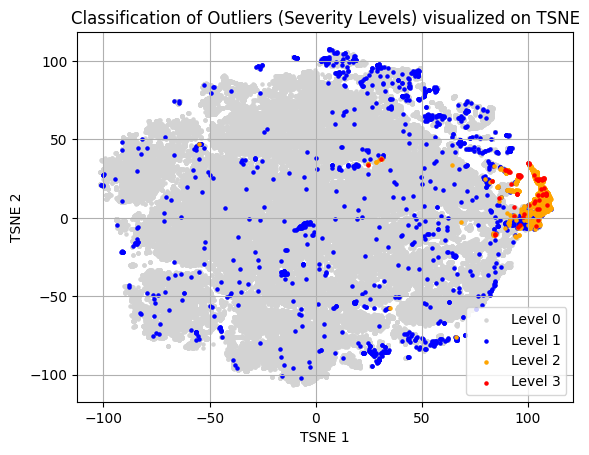

In [239]:
for level in [0, 1, 2, 3]:
    mask = outlier_level == level
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        color=colors[level],
        s=5,
        label=f"Level {level}",
    )

plt.title("Classification of Outliers (Severity Levels) visualized on TSNE")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.legend()
plt.grid(True)
plt.show()

In [240]:
df_outlier_info = pd.DataFrame(
    {
        "UMAP_1": X_umap[:, 0],
        "UMAP_2": X_umap[:, 1],
        "Outlier_Level": outlier_level.astype(int),
    }
)

# Salva
df_outlier_info.to_csv("dataset/outlier_levels_umap.csv", index=False)


In [241]:
mask_keep = (outlier_level == 0) | (outlier_level == 1)

df_cleaned = df[mask_keep].reset_index(drop=True)

print(f"Cleaned dataset shape: {df_cleaned.shape}")


Cleaned dataset shape: (115367, 66)


In [243]:
print(df.shape[0] - df_cleaned.shape[0])

1172


In [244]:
df_num_cleaned = df_cleaned.drop(cat, axis=1)

/var/folders/9v/f8wr4b9x0zdf_z5f4n5y_dr80000gn/T/ipykernel_71493/993210491.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
/var/folders/9v/f8wr4b9x0zdf_z5f4n5y_dr80000gn/T/ipykernel_71493/993210491.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)


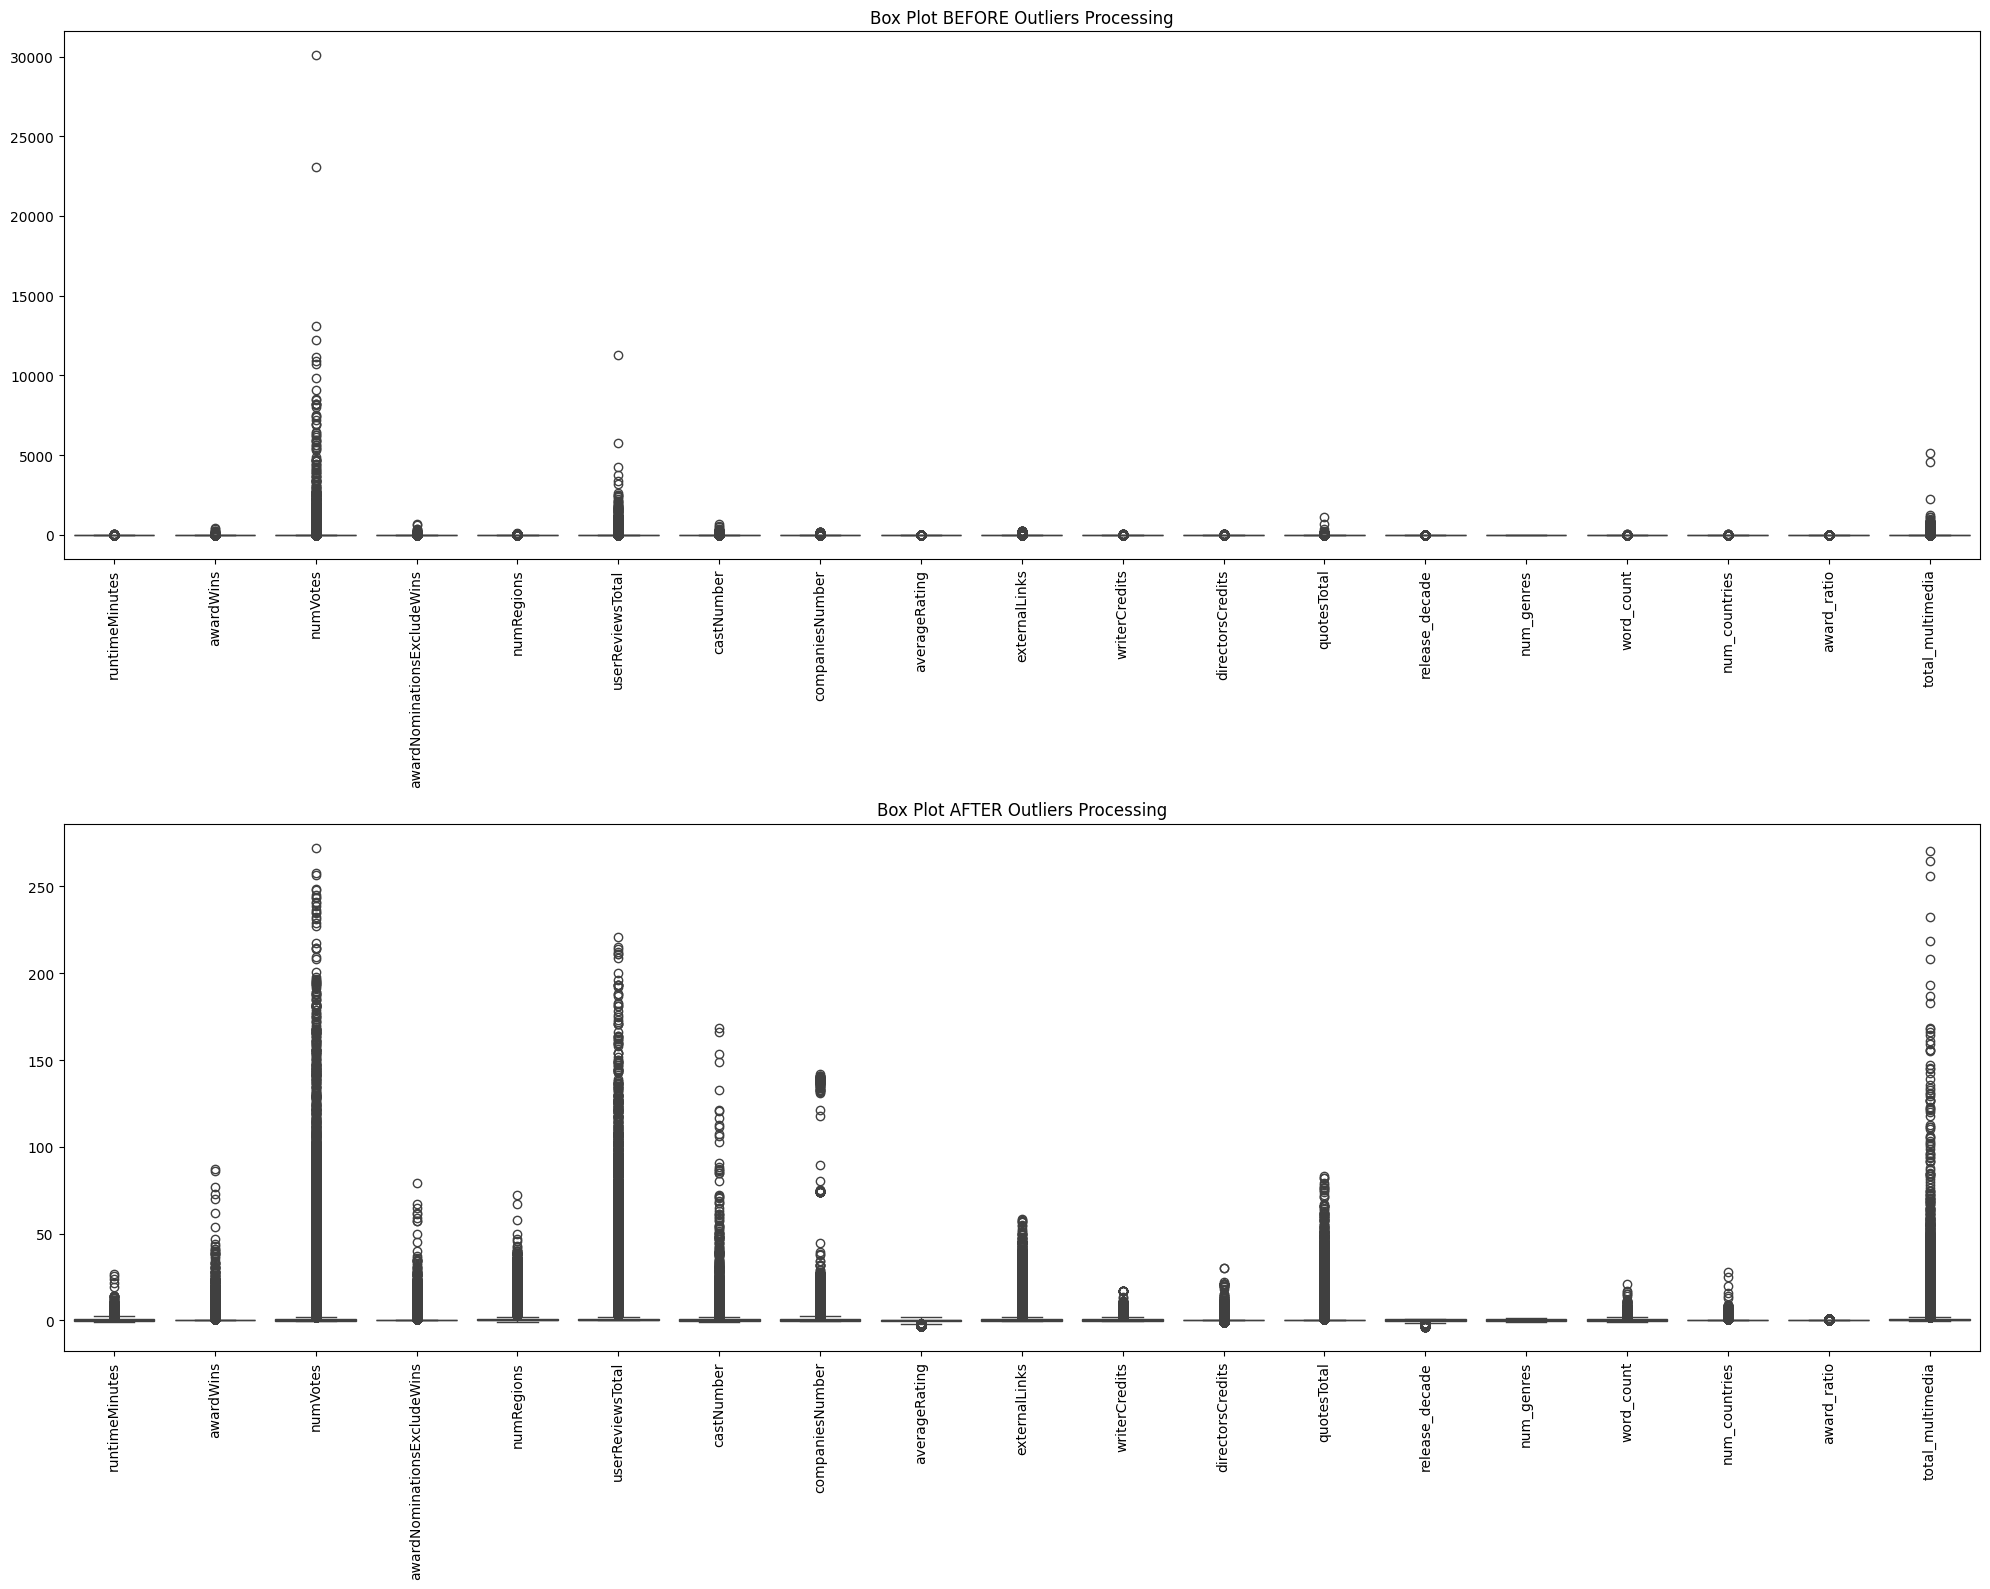

In [245]:
fig, axes = plt.subplots(2, 1, figsize=(20, 16))  # 2 rows, 1 column

sns.boxplot(data=df_num, ax=axes[0])
axes[0].set_title("Box Plot BEFORE Outliers Processing")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)


sns.boxplot(data=df_num_cleaned, ax=axes[1])
axes[1].set_title("Box Plot AFTER Outliers Processing")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)


plt.tight_layout()
plt.show()


In [247]:
df_cleaned.to_csv("dataset/train_post_outlier.csv")

In [248]:
df = pd.read_csv("dataset/train_post_outlier.csv")